<a href="https://colab.research.google.com/github/Samraat-22/first-project/blob/main/cat_dog_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Dataset ready!
✅ 4 corrupted images removed
 Model ready!
Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
 Data ready!
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 335s 528ms/step - accuracy: 0.8594 - loss: 0.3428 - val_accuracy: 0.9096 - val_loss: 0.2025
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 326s 522ms/step - accuracy: 0.9002 - loss: 0.2369 - val_accuracy: 0.9286 - val_loss: 0.1702
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 326s 522ms/step - accuracy: 0.9070 - loss: 0.2207 - val_accuracy: 0.9378 - val_loss: 0.1559
✅ Training complete!


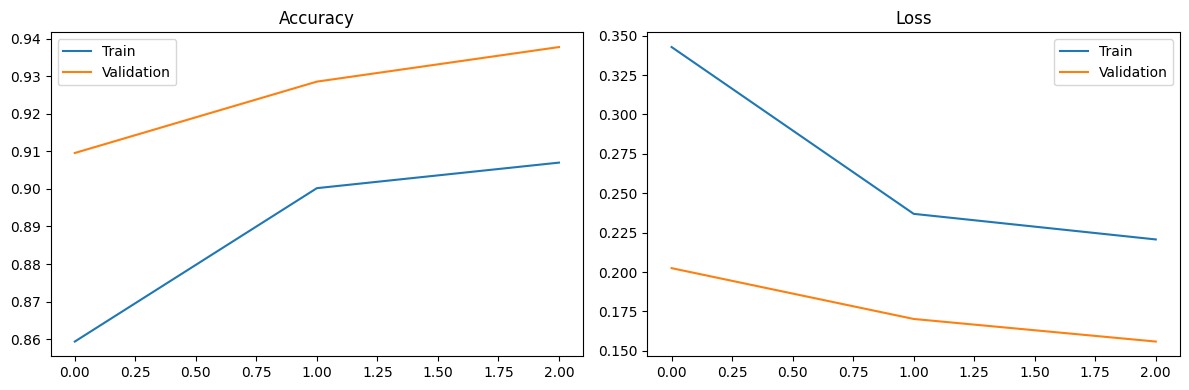

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
 Cat  —  100.0% confident
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


 Dog  —  100.0% confident
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/cat_dog_vgg16.h5'

In [27]:

import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image


from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
os.system('pip install kaggle -q')
os.system('kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset')
os.system('unzip -q microsoft-catsvsdogs-dataset.zip -d dataset')
print("✅ Dataset ready!")


removed = 0
for folder in ['Cat', 'Dog']:
    path = f'dataset/PetImages/{folder}'
    for fname in os.listdir(path):
        fpath = os.path.join(path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except:
            os.remove(fpath)
            removed += 1
print(f"✅ {removed} corrupted images removed")


base_model = tf.keras.applications.VGG16(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
for layer in base_model.layers:
    layer.trainable = False

inputs  = tf.keras.layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.Flatten()(x)
x       = tf.keras.layers.Dense(128, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
model   = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(" Model ready!")

train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    horizontal_flip=True, zoom_range=0.2, rotation_range=15
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_datagen.flow_from_directory(
    'dataset/PetImages', target_size=(224,224),
    batch_size=32, class_mode='categorical', subset='training', seed=42)
val_data = val_datagen.flow_from_directory(
    'dataset/PetImages', target_size=(224,224),
    batch_size=32, class_mode='categorical', subset='validation', seed=42)
print(" Data ready!")


history = model.fit(
    train_data, validation_data=val_data, epochs=3,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)
print("✅ Training complete!")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.legend()
plt.tight_layout()
plt.show()


def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x   = image.img_to_array(img) / 255.0
    x   = np.expand_dims(x, axis=0)
    pred = model.predict(x)[0]
    label = " Dog" if pred[1] > pred[0] else " Cat"
    confidence = max(pred) * 100
    print(f"{label}  —  {confidence:.1f}% confident")

predict_image('dataset/PetImages/Cat/10.jpg')
predict_image('dataset/PetImages/Dog/10.jpg')


model.save('cat_dog_vgg16.h5')
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy('cat_dog_vgg16.h5', '/content/drive/MyDrive/cat_dog_vgg16.h5')
